Install the relevant packages

We use DuckDB as a free in-memory database which we can query. It allows us to work through these massive datasets outside of Pandas, which struggled with the memory to process the .csv files.

In [1]:
!pip install -q duckdb wrds psycopg2-binary pyarrow

import os
import wrds
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from google.colab import drive
drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 72.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 85.1 MB/s eta 0:00:00
Mounted at /content/drive


We need to use Polars to work with the large dataset to avoid the RAM limitations of Pandas.

In [2]:
!pip install polars
import polars as pl

We upload the relevant BondDroid data from the Google Drive into DuckDB. Since we need to match the BondDroid data with the FISD WRDS data, we need to simplify the corporate bond names from the database first. We use fuzzy matching to strip out all the suffixes to standardise the names across the dataset.

The Bond Droid dataset on Dewey is available from Oct 05, 2023 to Mar 18, 2025 only.

In [3]:
sns.set_theme(style="whitegrid", context="paper")

path = "/content/drive/MyDrive/dewey"
cusip_df = os.path.join(path, "figi_cusip_map.parquet")
trace_data = os.path.join(path, "trace_raw.parquet")
panel_data = os.path.join(path, "aligned_trade_panel.parquet")
bonddroid = f"{path}/*.csv.gz"

wrds_login = "cgoelz"

start = '2023-10-05'
end = '2025-03-18'

def norm(s):
    s = str(s).upper()
    for junk in [",", ".", " INC", " CORP", " CORPORATION", " COMPANY",
                 " LTD", " LLC", " PLC", " GROUP", " HOLDINGS", " THE "]:
        s = s.replace(junk, " ")
    return " ".join(s.split())

The below cell queries the Bonddroid data and extracts the pricing failures, coverage heatmap and a maturity wall.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

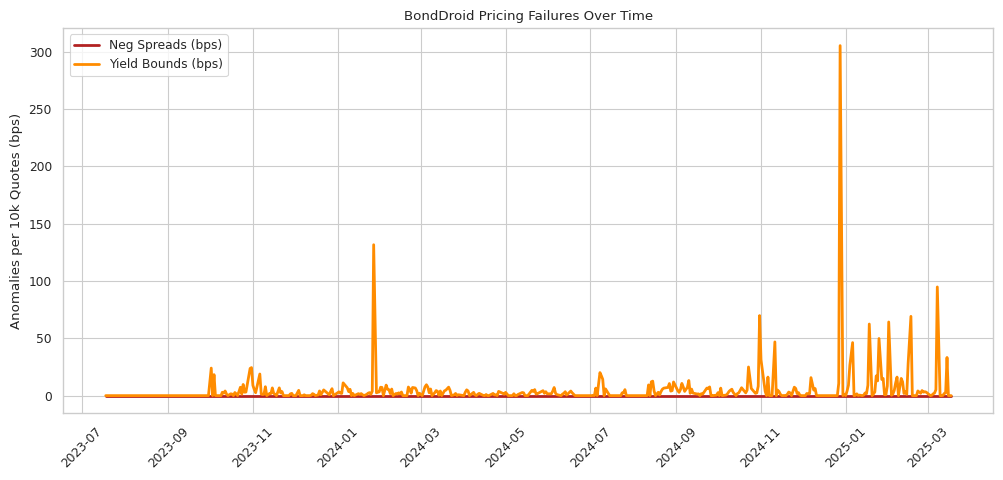

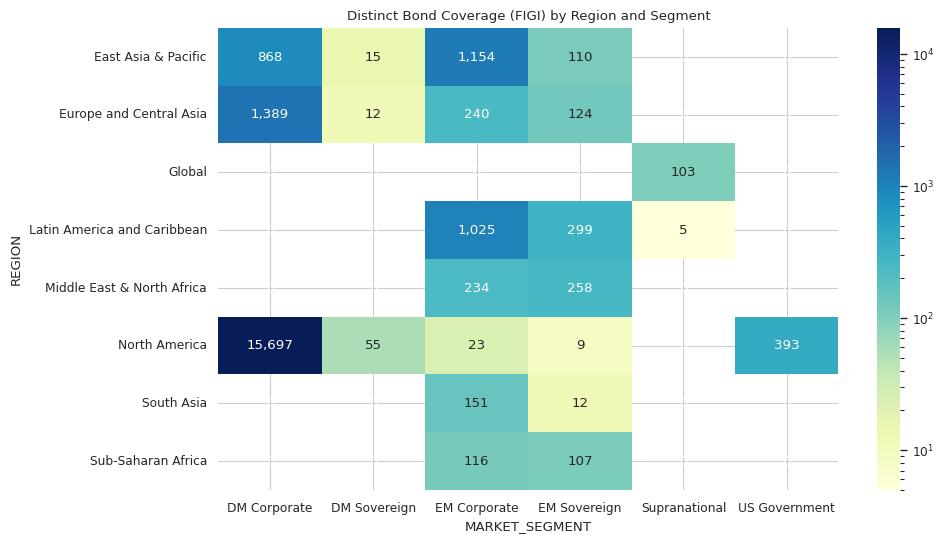

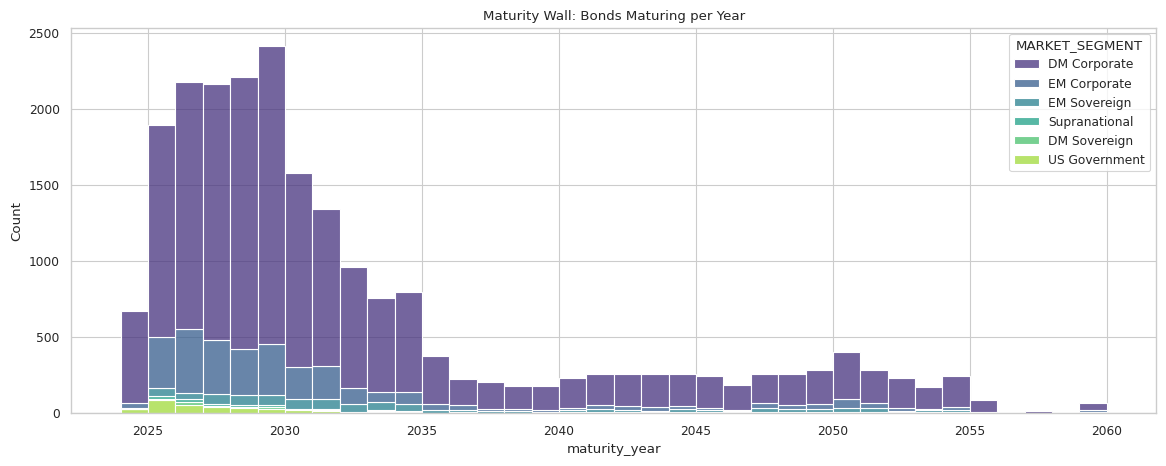

In [4]:
ts_query = f"""
SELECT
    MARKET_SEGMENT,
    CAST(SIGNAL_TIMESTAMP AS DATE) AS sig_date,
    COUNT(*) AS quote_volume,
    SUM(CASE WHEN ASK_PRICE <= BID_PRICE THEN 1 ELSE 0 END) AS neg_spread_err,
    SUM(CASE WHEN (BID_YIELD + ASK_YIELD)/2.0 < -0.10 OR (BID_YIELD + ASK_YIELD)/2.0 > 1.00 THEN 1 ELSE 0 END) AS yield_err,
    SUM(CASE WHEN (BID_PRICE + ASK_PRICE)/2.0 < 10.0 OR (BID_PRICE + ASK_PRICE)/2.0 > 250.0 THEN 1 ELSE 0 END) AS price_err
FROM read_csv_auto('{bonddroid}', union_by_name=True)
GROUP BY MARKET_SEGMENT, sig_date
"""

cs_query = f"""
SELECT
    MARKET_SEGMENT,
    REGION,
    EXTRACT(YEAR FROM CAST(MATURITY AS TIMESTAMP)) AS maturity_year,
    COUNT(DISTINCT FIGI) AS distinct_bonds
FROM read_csv_auto('{bonddroid}', union_by_name=True)
WHERE MATURITY IS NOT NULL
GROUP BY MARKET_SEGMENT, REGION, maturity_year
"""

con = duckdb.connect()
ts_df = con.execute(ts_query).df()
cs_df = con.execute(cs_query).df()
con.close()

daily_errors = ts_df.groupby('sig_date')[['quote_volume', 'neg_spread_err', 'yield_err', 'price_err']].sum().reset_index()
daily_errors['neg_spread_bps'] = (daily_errors['neg_spread_err'] / daily_errors['quote_volume']) * 10000
daily_errors['yield_err_bps'] = (daily_errors['yield_err'] / daily_errors['quote_volume']) * 10000

plt.figure(figsize=(12, 5))
plt.plot(daily_errors['sig_date'], daily_errors['neg_spread_bps'], color='firebrick', label='Neg Spreads (bps)', lw=2)
plt.plot(daily_errors['sig_date'], daily_errors['yield_err_bps'], color='darkorange', label='Yield Bounds (bps)', lw=2)
plt.title("BondDroid Pricing Failures Over Time")
plt.ylabel("Anomalies per 10k Quotes (bps)")
plt.legend(); plt.xticks(rotation=45); plt.show()

heatmap_data = cs_df.groupby(['REGION', 'MARKET_SEGMENT'])['distinct_bonds'].sum().unstack(fill_value=0)
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt=",.0f", cmap="YlGnBu", norm=plt.matplotlib.colors.LogNorm())
plt.title("Distinct Bond Coverage (FIGI) by Region and Segment")
plt.show()

maturity_df = cs_df[(cs_df['maturity_year'] >= 2024) & (cs_df['maturity_year'] <= 2060)]
plt.figure(figsize=(14, 5))
sns.histplot(data=maturity_df, x='maturity_year', weights='distinct_bonds', hue='MARKET_SEGMENT',
             multiple='stack', palette='viridis', bins=36)
plt.title("Maturity Wall: Bonds Maturing per Year")
plt.show()

In the following cell, we generate a SQL Query to extract the FISD Trace bond data via DuckDB and then matches them.

Since TRACE data is based on CUSIP, we cannot directly link it to the BondDroid data, which uses a FIGI as identifier.

Therefore we need to create a lookup table that matches the FIGI with CUSIP data which is where the core standardised corporate issuer names come in. We match the BondDroid with the FISD information from WRDS as follows:

1.   Matching the bonds against their issuer names and maturity as per the prospectus (m1).
2.   Any leftover bonds are matched against the FISD CUSIP name (m2).

We then remove all FISD duplicates and check our hit rate for matches to create a master lookup table which we save as cusip_df in .parquet format.

In [5]:
con = duckdb.connect()

bd_query = f"""
    SELECT DISTINCT
        FIGI,
        ISSUER_NAME,
        MARKET_SEGMENT,
        REGION,
        ROUND(COUPON, 3) AS COUPON,
        CAST(MATURITY AS DATE) AS MATURITY
    FROM read_csv_auto('{bonddroid}')
    WHERE MATURITY IS NOT NULL AND ISSUER_NAME IS NOT NULL
"""
bd = con.execute(bd_query).df()

print("Connecting to WRDS")
db = wrds.Connection(wrds_username=wrds_login)

fisd_query = """
    SELECT i.complete_cusip            AS cusip,
           i.issue_id,
           i.issuer_id,
           i.offering_date,
           i.maturity                  AS maturity,
           i.bond_type,
           i.isin,
           i.prospectus_issuer_name    AS issuer_name_fisd,
           u.cusip_name                AS cusip_name_fisd
    FROM   fisd.fisd_issue   i
    JOIN   fisd.fisd_issuer  u  USING (issuer_id)
    WHERE  i.foreign_currency = 'N'
      AND  i.maturity BETWEEN '2023-01-01' AND '2080-12-31'
"""
fisd = db.raw_sql(fisd_query)

os.makedirs(path, exist_ok=True)

print("Matching names and enforcing unique CUSIPs")
bd["MATURITY"]   = pd.to_datetime(bd["MATURITY"]).dt.date
fisd["maturity"] = pd.to_datetime(fisd["maturity"]).dt.date

bd["nm"]          = bd["ISSUER_NAME"].map(norm)
fisd["nm_pros"]   = fisd["issuer_name_fisd"].map(norm)
fisd["nm_cusip"]  = fisd["cusip_name_fisd"].map(norm)

m1 = bd.merge(fisd, how="left", left_on=["nm", "MATURITY"], right_on=["nm_pros", "maturity"])
matched = m1.dropna(subset=["cusip"])

remainder = bd[~bd["FIGI"].isin(matched["FIGI"])]
m2 = remainder.merge(fisd, how="left", left_on=["nm", "MATURITY"], right_on=["nm_cusip", "maturity"])
matched2 = m2.dropna(subset=["cusip"])

all_matches = pd.concat([matched, matched2], ignore_index=True)
# Pick one FIGI per CUSIP to fix the CUSIP side mapping
cusip_map = (all_matches
             .sort_values(["cusip", "FIGI"])
             .drop_duplicates(subset=["cusip"], keep="first")
             .reset_index(drop=True))

final_map = cusip_map[[
    'FIGI',
    'cusip',
    'ISSUER_NAME',
    'MATURITY',
    'COUPON',
    'MARKET_SEGMENT',
    'bond_type',
    'isin'
]].copy()

if 'REGION' not in final_map.columns:
    region_lookup = bd[['FIGI', 'REGION']].drop_duplicates()
    final_map = final_map.merge(region_lookup, on='FIGI', how='left')

final_map.to_parquet(cusip_df, index=False)
print(f"Saved {cusip_df}. Bonds: {len(final_map):,}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Connecting to WRDS
Enter your WRDS username [cgoelz]:cgoelz
Enter your password:··········
WRDS recommends setting up a .pgpass file.
Create .pgpass file now [y/n]?: y
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
Matching names and enforcing unique CUSIPs
Saved /content/drive/MyDrive/dewey/figi_cusip_map.parquet. Bonds: 4,183


The following cell downloads the corresponding TRACE data using the cusip_df table which contains the relevant CUSIP information for the bonds in BondDroid. This information is then saved as trace_data in parquet format.

In [6]:
def download_trace_data():

    db = wrds.Connection(wrds_username=wrds_login)

    mapping_df = pd.read_parquet(cusip_df)
    cusips = mapping_df['cusip'].dropna().unique().tolist()

    cusips_sql_array = ", ".join([f"'{c}'" for c in cusips])

    print(f"TRACE Enhanced (BTDS) data. {len(cusips)} mapped CUSIPs")

    trace_query = f"""
        WITH cusip_list AS (
            SELECT unnest(ARRAY[{cusips_sql_array}]) AS cusip_id
        )
        SELECT
            t.cusip_id AS cusip,
            t.trd_exctn_dt AS trade_date,
            t.trd_exctn_tm AS trade_time,
            t.rptd_pr AS trace_price,
            t.yld_pt AS trace_yield,
            t.entrd_vol_qt AS volume,
            t.rpt_side_cd AS side
        FROM trace.trace_enhanced t
        INNER JOIN cusip_list tmp ON t.cusip_id = tmp.cusip_id
        WHERE t.trd_exctn_dt BETWEEN '{start}' AND '{end}'
          AND t.trc_st = 'T'
    """

    trace_df = db.raw_sql(trace_query)
    db.close()

    trace_df['trade_ts'] = pd.to_datetime(
        trace_df['trade_date'].astype(str) + ' ' + trace_df['trade_time'].astype(str)
    )
    trace_df.drop(columns=['trade_date', 'trade_time'], inplace=True)

    trace_df.to_parquet(trace_data, index=False)
    print(f"Saved {len(trace_df):,} trades to {trace_data}")

In [7]:
download_trace_data()

Loading library list...
Done
TRACE Enhanced (BTDS) data. 4161 mapped CUSIPs
Saved 13,100,947 trades to /content/drive/MyDrive/dewey/trace_raw.parquet


This cell uses the bonddroid, trace_data and cusip_df files to combine them into a single matching database which we can use for our machine learning tasks. Since there are millions of intraday prices and trades, we need to use DuckDB to combine them efficiently with ASOF LEFT JOIN where DuckDB queries trace_data to find matching bonddroid prices.

The query exceeds the Colab RAM limits so we need to use DuckDB as a temporary storage until the finished query is saved as parquet file.

This cell creates the combined panel_data dataset in parquet.

In [8]:
os.makedirs('/content/duckdb_temp', exist_ok=True)
con = duckdb.connect()
con.execute("PRAGMA temp_directory='/content/duckdb_temp'")
con.execute("PRAGMA memory_limit='10GB'")

cache_query = f"""
CREATE TEMP TABLE cached_bd AS
SELECT
    FIGI,
    CAST(RATES_TIMESTAMP AS TIMESTAMP) AS bd_ts,
    (BID_PRICE + ASK_PRICE) / 2.0 AS bd_mid_px,
    (BID_YIELD + ASK_YIELD) / 2.0 AS bd_mid_yield,
    ABS(ASK_PRICE - BID_PRICE) AS bd_px_spread,
    AVG_DAILY_TRADE_COUNT_60, TIMES_TRADED_60, TIME_SINCE_LAST_TRADE,
    BID_OAS, ASK_OAS, DOS_OAS_BID, DOS_OAS_ASK,
    SOS_OAS_BID, SOS_OAS_ASK, BID_SOT, ASK_SOT,
    DURATION_MID, CONVEXITY_MID, COUPON,
    CAST(MATURITY AS DATE) AS MATURITY,
    BONDDROID_SECTOR, BONDDROID_INDUSTRY, TRIGGER_TYPE,
    (IS_CLOSE IS NOT NULL AND UPPER(CAST(IS_CLOSE AS VARCHAR)) = 'TRUE') AS is_snapshot,
    (CASE
        WHEN (BID_YIELD + ASK_YIELD)/2.0 <= 0 OR (BID_YIELD + ASK_YIELD)/2.0 > 0.50 THEN TRUE
        WHEN ABS((BID_OAS + ASK_OAS)/2.0) > 20.0 THEN TRUE
        WHEN ABS(BID_SOT) > 21000 OR ABS(ASK_SOT) > 21000 THEN TRUE
        ELSE FALSE
    END) AS bd_pricing_failure
FROM read_csv_auto('{bonddroid}', union_by_name=True)
WHERE BID_PRICE > 0 AND FIGI IN (SELECT DISTINCT FIGI FROM read_parquet('{cusip_df}'))
QUALIFY ROW_NUMBER() OVER (PARTITION BY FIGI, bd_ts ORDER BY is_snapshot ASC, RATES_TIMESTAMP DESC) = 1
"""
con.execute(cache_query)

merge_query = f"""
COPY (WITH cross_ref AS (SELECT DISTINCT FIGI, cusip, REGION, MARKET_SEGMENT FROM read_parquet('{cusip_df}')),
    trace_dedup AS (
        SELECT * FROM read_parquet('{trace_data}')
        QUALIFY ROW_NUMBER() OVER (PARTITION BY cusip, trade_ts, trace_price, volume, side ORDER BY trade_ts) = 1
    )
    SELECT
        t.cusip, t.trace_price, t.trace_yield, t.volume AS trade_volume, t.side AS trade_side,
        t.trade_ts, c.FIGI, c.REGION, c.MARKET_SEGMENT, b.bd_ts,
        b.bd_mid_px, b.bd_mid_yield, b.bd_px_spread, b.AVG_DAILY_TRADE_COUNT_60,
        b.TIMES_TRADED_60, b.TIME_SINCE_LAST_TRADE, b.BID_OAS, b.ASK_OAS,
        b.BID_SOT, b.ASK_SOT, b.DURATION_MID, b.CONVEXITY_MID, b.COUPON, b.MATURITY,
        b.BONDDROID_SECTOR, b.BONDDROID_INDUSTRY, b.TRIGGER_TYPE, b.is_snapshot,
        b.bd_pricing_failure,
        date_diff('second', b.bd_ts, t.trade_ts) AS quote_age_seconds
    FROM trace_dedup t
    INNER JOIN cross_ref c ON t.cusip = c.cusip
    ASOF LEFT JOIN cached_bd b
        ON c.FIGI = b.FIGI AND t.trade_ts >= b.bd_ts
    WHERE date_diff('second', b.bd_ts, t.trade_ts) <= 3600
) TO '{panel_data}' (FORMAT PARQUET)
"""
con.execute(merge_query)
con.close()
print(f"Panel saved: {panel_data}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Panel saved: /content/drive/MyDrive/dewey/aligned_trade_panel.parquet


In [9]:
panel_preview = pl.scan_parquet(panel_data).head(10).collect()
print("Columns in aligned_trade_panel.parquet:")
print(panel_preview.columns)

display(panel_preview)

Columns in aligned_trade_panel.parquet:
['cusip', 'trace_price', 'trace_yield', 'trade_volume', 'trade_side', 'trade_ts', 'FIGI', 'REGION', 'MARKET_SEGMENT', 'bd_ts', 'bd_mid_px', 'bd_mid_yield', 'bd_px_spread', 'AVG_DAILY_TRADE_COUNT_60', 'TIMES_TRADED_60', 'TIME_SINCE_LAST_TRADE', 'BID_OAS', 'ASK_OAS', 'BID_SOT', 'ASK_SOT', 'DURATION_MID', 'CONVEXITY_MID', 'COUPON', 'MATURITY', 'BONDDROID_SECTOR', 'BONDDROID_INDUSTRY', 'TRIGGER_TYPE', 'is_snapshot', 'bd_pricing_failure', 'quote_age_seconds']


cusip,trace_price,trace_yield,trade_volume,trade_side,trade_ts,FIGI,REGION,MARKET_SEGMENT,bd_ts,bd_mid_px,bd_mid_yield,bd_px_spread,AVG_DAILY_TRADE_COUNT_60,TIMES_TRADED_60,TIME_SINCE_LAST_TRADE,BID_OAS,ASK_OAS,BID_SOT,ASK_SOT,DURATION_MID,CONVEXITY_MID,COUPON,MATURITY,BONDDROID_SECTOR,BONDDROID_INDUSTRY,TRIGGER_TYPE,is_snapshot,bd_pricing_failure,quote_age_seconds
str,f64,f64,f64,str,datetime[ns],str,str,str,datetime[μs],f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,date,str,str,str,bool,bool,i64
"""655664AH3""",92.759,8.964649,3000.0,"""B""",2023-10-06 09:14:53,"""BBG00005NKC4""","""North America""","""DM Corporate""",2023-10-06 09:00:01,93.418334,0.087733,0.418,13.917,835.02,"""0-24""",408.510943,396.436728,412.945828,400.862888,3.683941,0.165802,0.0695,2028-03-15,"""Retail Trade""","""Family Clothing Stores ""","""ats1_primary""",false,true,892
"""655664AH3""",92.425667,9.06205,3000.0,"""B""",2023-10-06 09:14:54,"""BBG00005NKC4""","""North America""","""DM Corporate""",2023-10-06 09:00:01,93.418334,0.087733,0.418,13.917,835.02,"""0-24""",408.510943,396.436728,412.945828,400.862888,3.683941,0.165802,0.0695,2028-03-15,"""Retail Trade""","""Family Clothing Stores ""","""ats1_primary""",false,true,893
"""655664AH3""",92.759,8.964649,3000.0,"""S""",2023-10-06 09:14:54,"""BBG00005NKC4""","""North America""","""DM Corporate""",2023-10-06 09:00:01,93.418334,0.087733,0.418,13.917,835.02,"""0-24""",408.510943,396.436728,412.945828,400.862888,3.683941,0.165802,0.0695,2028-03-15,"""Retail Trade""","""Family Clothing Stores ""","""ats1_primary""",false,true,893
"""655664AH3""",93.58,8.726554,10000.0,"""S""",2023-10-06 11:14:58,"""BBG00005NKC4""","""North America""","""DM Corporate""",2023-10-06 11:00:02,93.394831,0.087801,0.418,13.917,835.02,"""0-24""",408.510943,396.436728,412.957911,400.871275,3.683941,0.165802,0.0695,2028-03-15,"""Retail Trade""","""Family Clothing Stores ""","""ats1_primary""",false,true,896
"""655664AH3""",93.48,8.755418,10000.0,"""S""",2023-10-06 11:14:58,"""BBG00005NKC4""","""North America""","""DM Corporate""",2023-10-06 11:00:02,93.394831,0.087801,0.418,13.917,835.02,"""0-24""",408.510943,396.436728,412.957911,400.871275,3.683941,0.165802,0.0695,2028-03-15,"""Retail Trade""","""Family Clothing Stores ""","""ats1_primary""",false,true,896
"""655664AH3""",93.48,8.755418,10000.0,"""B""",2023-10-06 11:14:58,"""BBG00005NKC4""","""North America""","""DM Corporate""",2023-10-06 11:00:02,93.394831,0.087801,0.418,13.917,835.02,"""0-24""",408.510943,396.436728,412.957911,400.871275,3.683941,0.165802,0.0695,2028-03-15,"""Retail Trade""","""Family Clothing Stores ""","""ats1_primary""",false,true,896
"""655664AH3""",93.7,8.691966,25000.0,"""S""",2023-10-06 11:42:51,"""BBG00005NKC4""","""North America""","""DM Corporate""",2023-10-06 11:00:02,93.394831,0.087801,0.418,13.917,835.02,"""0-24""",408.510943,396.436728,412.957911,400.871275,3.683941,0.165802,0.0695,2028-03-15,"""Retail Trade""","""Family Clothing Stores ""","""ats1_primary""",false,true,2569
"""655664AH3""",93.8,8.663183,25000.0,"""S""",2023-10-06 11:42:52,"""BBG00005NKC4""","""North America""","""DM Corporate""",2023-10-06 11:00:02,93.394831,0.087801,0.418,13.917,835.02,"""0-24""",408.510943,396.436728,412.957911,400.871275,3.683941,0.165802,0.0695,2028-03-15,"""Retail Trade""","""Family Clothing Stores ""","""ats1_primary""",false,true,2570
"""655664AH3""",93.7,8.691966,25000.0,"""B""",2023-10-06 11:42:52,"""BBG00005NKC4""","""North America""","""DM Corporate""",2023-10-06 11:00:02,93.394831,0.087801,0.418,13.917,835.02,"""0-24""",408.510943,396.436728,412.957911,400.871275,3.683941,0.165802,0.0695,2028-03-15,"""Retail Trade""","""Family Clothing Stores ""","""ats1_primary""",false,true,2570


In the following cell we query the combined dataset and graphically illustrate the data we extracted from BondDroid and WRDS.

The cell below was quite memory heavy due to the size of the dataset so in case it crashes the runtime, I've written it so it can run on its own and load the panel from the drive directly.

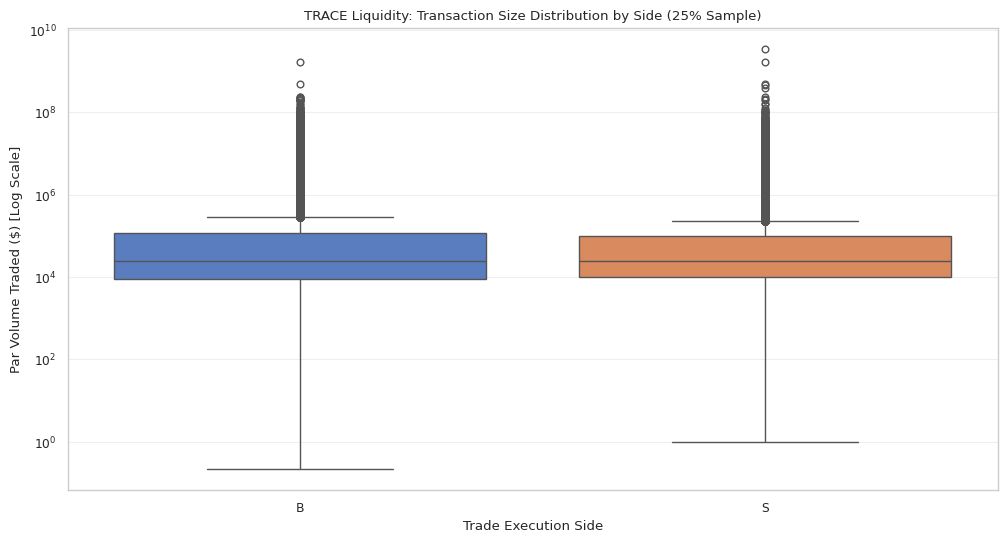

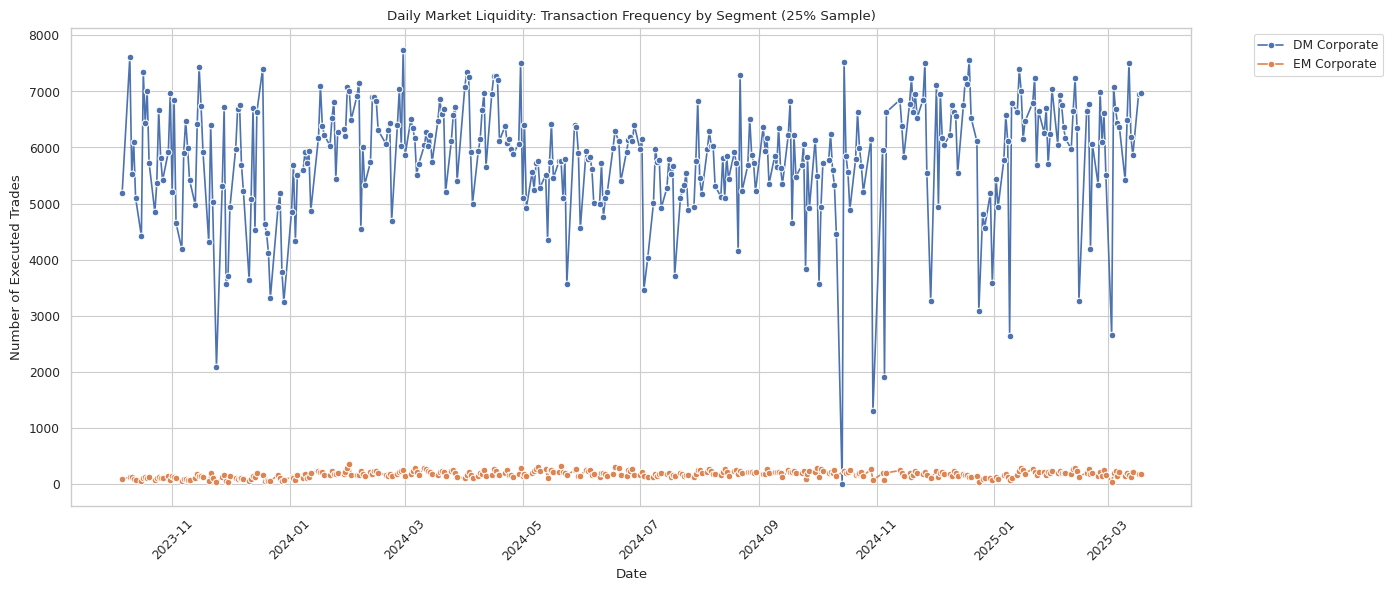

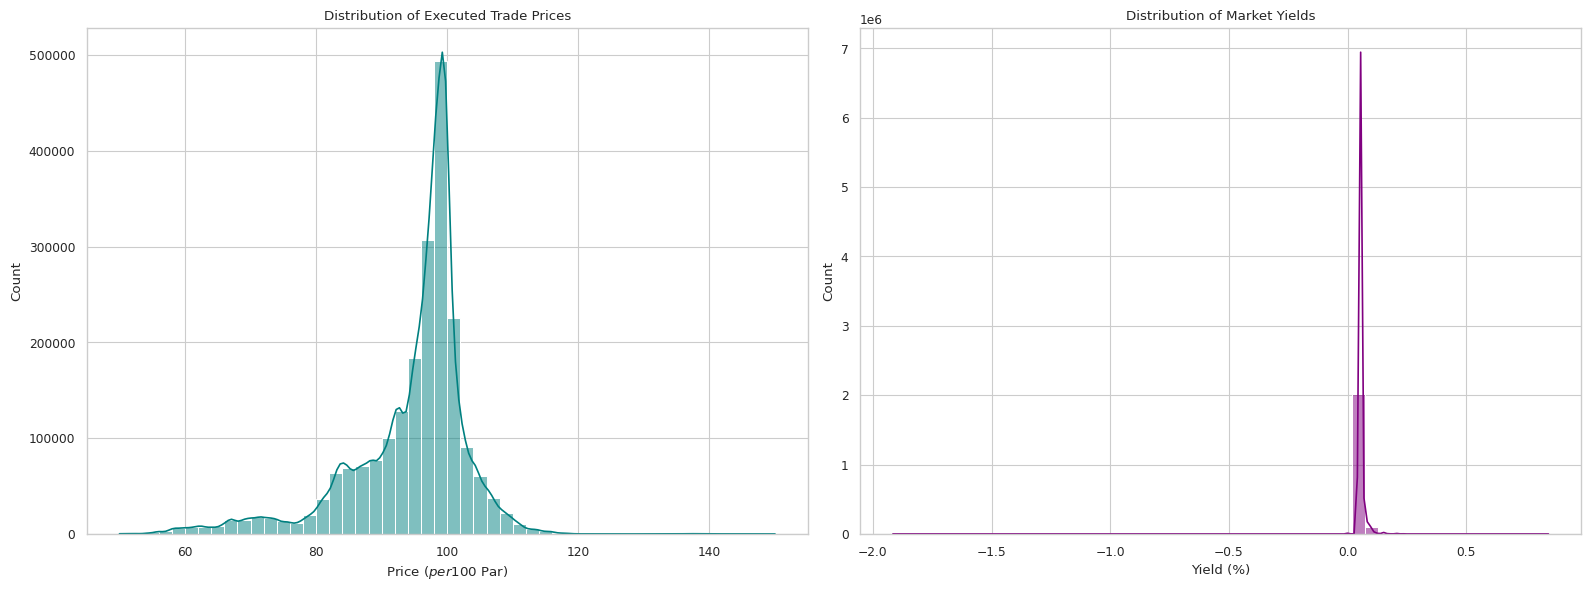


 Summary Statistics (Estimated from Sample)
              count   median           mean
trade_side                                 
S           1135071  25000.0  283296.765393
B            992260  25000.0  322710.205939


In [10]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

path = "/content/drive/MyDrive/dewey"
panel_data = os.path.join(path, "aligned_trade_panel.parquet")

if os.path.exists(panel_data):

    lf = pl.scan_parquet(panel_data)

    total_rows = pl.read_parquet(panel_data, low_memory=True).height
    sample_size = int(total_rows * 0.25)

    df_sample = lf.head(sample_size).collect().to_pandas()

    df_sample['trade_date'] = pd.to_datetime(df_sample['trade_ts']).dt.date

    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df_sample, x='trade_side', y='trade_volume', hue='trade_side', palette='muted', legend=False)
    plt.yscale('log')
    plt.title("TRACE Liquidity: Transaction Size Distribution by Side (25% Sample)")
    plt.ylabel("Par Volume Traded ($) [Log Scale]")
    plt.xlabel("Trade Execution Side")
    plt.grid(axis='y', alpha=0.3)
    plt.show()

    plt.figure(figsize=(14, 6))
    daily_velocity = df_sample.groupby(['trade_date', 'MARKET_SEGMENT']).size().reset_index(name='n_trades')
    sns.lineplot(data=daily_velocity, x='trade_date', y='n_trades', hue='MARKET_SEGMENT', marker='o')
    plt.title("Daily Market Liquidity: Transaction Frequency by Segment (25% Sample)")
    plt.ylabel("Number of Executed Trades")
    plt.xlabel("Date")
    plt.xticks(rotation=45)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.histplot(df_sample['trace_price'].clip(lower=50, upper=150), bins=50, kde=True, ax=axes[0], color='teal')
    axes[0].set_title("Distribution of Executed Trade Prices")
    axes[0].set_xlabel("Price ($ per $100 Par)")

    sns.histplot(df_sample['bd_mid_yield'].dropna(), bins=50, kde=True, ax=axes[1], color='purple')
    axes[1].set_title("Distribution of Market Yields")
    axes[1].set_xlabel("Yield (%)")

    plt.tight_layout()
    plt.show()

    df_panel = df_sample

    print("\n Summary Statistics (Estimated from Sample)")
    print(df_panel.groupby('trade_side')['trade_volume'].agg(['count', 'median', 'mean']).sort_values('count', ascending=False))
else:
    print(f"Error: {panel_data} not found. Please ensure the merge cell has run successfully.")

We check how many trades in our matched panel are associated with quotes that triggered bd_pricing_failure.

Percentage of records flagged as pricing failures:
bd_pricing_failure
True     97.066136
False     2.933864
Name: proportion, dtype: float64


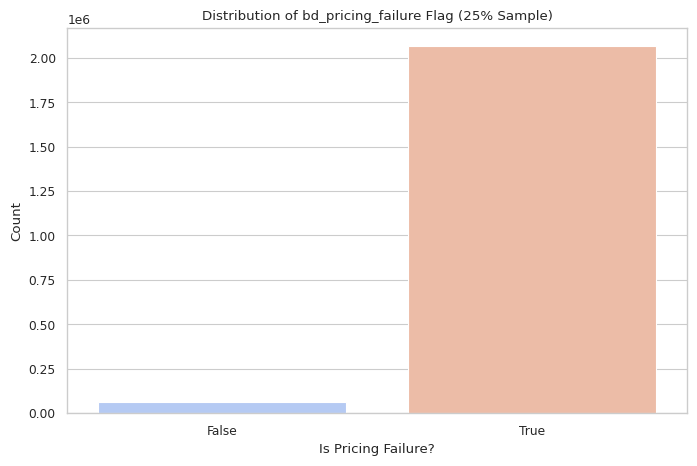

In [11]:
failure_counts = df_panel['bd_pricing_failure'].value_counts(normalize=True) * 100
print("Percentage of records flagged as pricing failures:")
print(failure_counts)

plt.figure(figsize=(8, 5))
sns.countplot(data=df_panel, x='bd_pricing_failure', hue='bd_pricing_failure', palette='coolwarm', legend=False)
plt.title("Distribution of bd_pricing_failure Flag (25% Sample)")
plt.xlabel("Is Pricing Failure?")
plt.ylabel("Count")

plt.show()

Using the combined dataset (panel_data), we can now clean the remaining information to prepare it for the machine learning tasks. First, we create our y-label which is the absolute pricing error ("target_abs_error").

We then remove all NaNs from the trade_volume and bd_px_spread columns and enter 0 instead.

Thereafter, we forward-fill (ffill) and backward-fill (bfill) any missing intraday prices and yields to ensure we have prices for each timestamp. We assume that an intraday price is missing for a timestamp, that the previous intraday price is valid.

Since bond trades are often large institutional volumes, we need to ensure that the significant variance between the trade volumes don't impact the machine learning model. Therefore we use the log_volume and then normalise the different units into normalised values with mean = 0 and sigma = 1.

Finally, we change the categorical values for Market Segment and Region, into numerical values (1,0) so that the machine learning model can interpret them.

Given the size of the dataframe (over 13m records), we need to use polars to clean the variables.

In [12]:
lf = pl.scan_parquet(panel_data)
lf = lf.sort(['FIGI', 'trade_ts'])

pricing_cols = ['bd_mid_px', 'bd_mid_yield', 'DURATION_MID', 'CONVEXITY_MID']
lf = lf.with_columns([
    pl.col(c).fill_null(strategy='forward').fill_null(strategy='backward').over('FIGI')
    for c in pricing_cols])

lf = lf.with_columns([
    (pl.col('bd_mid_px') - pl.col('trace_price')).abs().cast(pl.Float32).alias('target_abs_error'),
    (pl.col('trade_volume') + 1).log().cast(pl.Float32).alias('log_volume'),
    ((pl.col('BID_OAS') + pl.col('ASK_OAS')) / 2.0).cast(pl.Float32).alias('OAS_MID'),
    ((pl.col('BID_SOT') + pl.col('ASK_SOT')) / 2.0).cast(pl.Float32).alias('SOT_MID')])

df_ml = lf.collect()

df_ml = df_ml.with_columns([
    pl.col('is_snapshot').fill_null(False),
    pl.col('bd_pricing_failure').fill_null(False),
    pl.col('AVG_DAILY_TRADE_COUNT_60').fill_null(0.0),
    pl.col('TIMES_TRADED_60').fill_null(0.0)])

num_cols = ['bd_mid_px', 'bd_mid_yield', 'bd_px_spread', 'log_volume', 'quote_age_seconds', 'OAS_MID', 'SOT_MID']
df_ml = df_ml.with_columns([
    ((pl.col(c) - pl.col(c).mean()) / pl.col(c).std()).cast(pl.Float32).alias(c)
    for c in num_cols if c in df_ml.columns])

cat_cols = ['MARKET_SEGMENT', 'REGION', 'BONDDROID_SECTOR', 'TRIGGER_TYPE']
df_ml = df_ml.to_dummies(cat_cols, drop_first=False)

print(f"ML Ready Shape: {df_ml.shape}")

ML Ready Shape: (8509326, 55)


The following cell converts the Polars dataframe back to a Pandas dataframe for Machine Learning tasks.

In [13]:
df_final = df_ml.to_pandas()

To ensure that the cleaned, normalized, and encoded data is persisted for both unsupervised and supervised learning tasks, we save the df_final dataframe as a parquet file.

In [15]:
final_path = os.path.join(path, "final_ml_panel.parquet")
df_final.to_parquet(final_path, index=False)
print(f"Saved Final Panel: {final_path}")
print(f"Size: {len(df_final):,}")

Saved Final Panel: /content/drive/MyDrive/dewey/final_ml_panel.parquet
Size: 8,509,326


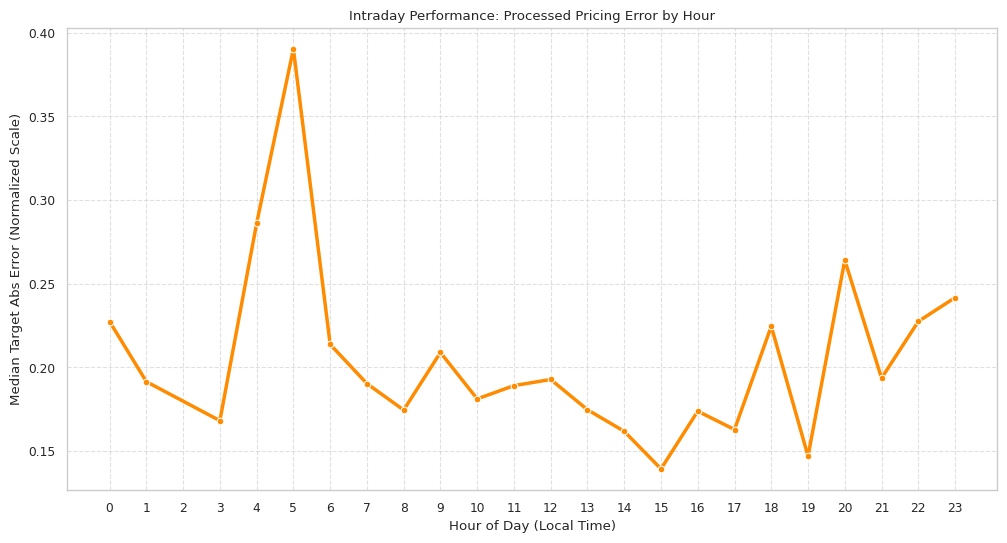

In [16]:
df_final['hour'] = pd.to_datetime(df_final['bd_ts']).dt.hour

plt.figure(figsize=(12, 6))
hourly_error = df_final.groupby('hour')['target_abs_error'].median()

sns.lineplot(x=hourly_error.index, y=hourly_error.values, marker='o', color='darkorange', linewidth=2.5)
plt.title("Intraday Performance: Processed Pricing Error by Hour")
plt.xlabel("Hour of Day (Local Time)")
plt.ylabel("Median Target Abs Error (Normalized Scale)")
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

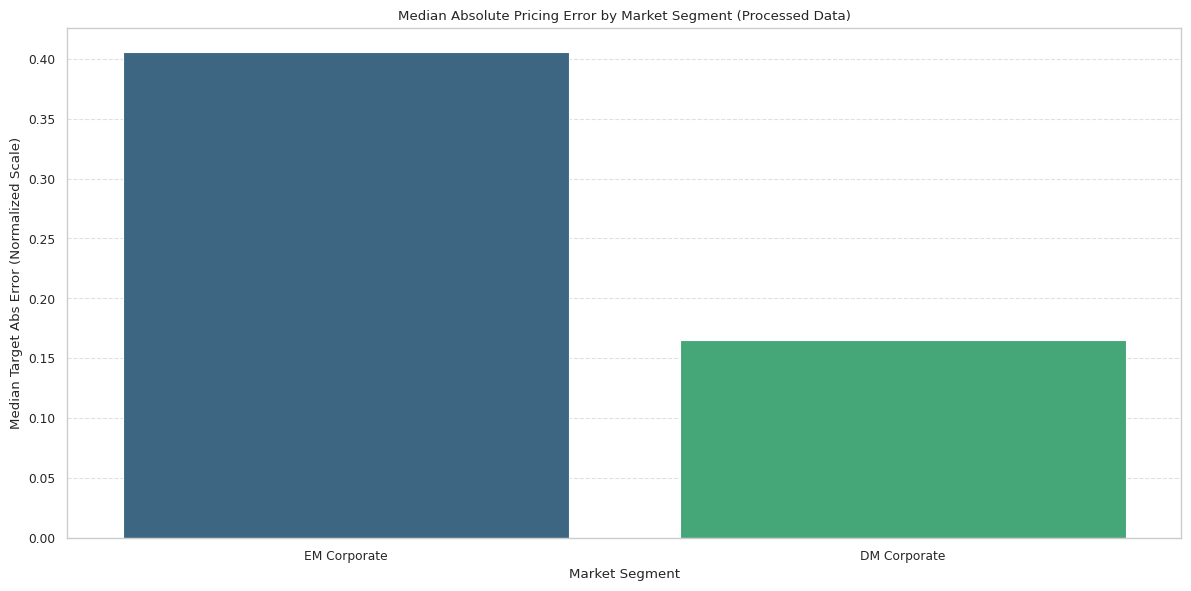

In [17]:
plt.figure(figsize=(12, 6))

segment_cols = [c for c in df_final.columns if 'MARKET_SEGMENT_' in c]

segment_medians = {}
for col in segment_cols:
    segment_name = col.replace('MARKET_SEGMENT_', '')
    median_val = df_final[df_final[col] == 1.0]['target_abs_error'].median()
    segment_medians[segment_name] = median_val

ser_segment_error = pd.Series(segment_medians).sort_values(ascending=False)

sns.barplot(x=ser_segment_error.index, y=ser_segment_error.values, hue=ser_segment_error.index, palette='viridis', legend=False)
plt.title("Median Absolute Pricing Error by Market Segment (Processed Data)")
plt.xlabel("Market Segment")
plt.ylabel("Median Target Abs Error (Normalized Scale)")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

We visualize quote_age_seconds to understand the distribution of time lags between the latest BondDroid quote and the subsequent TRACE trade.

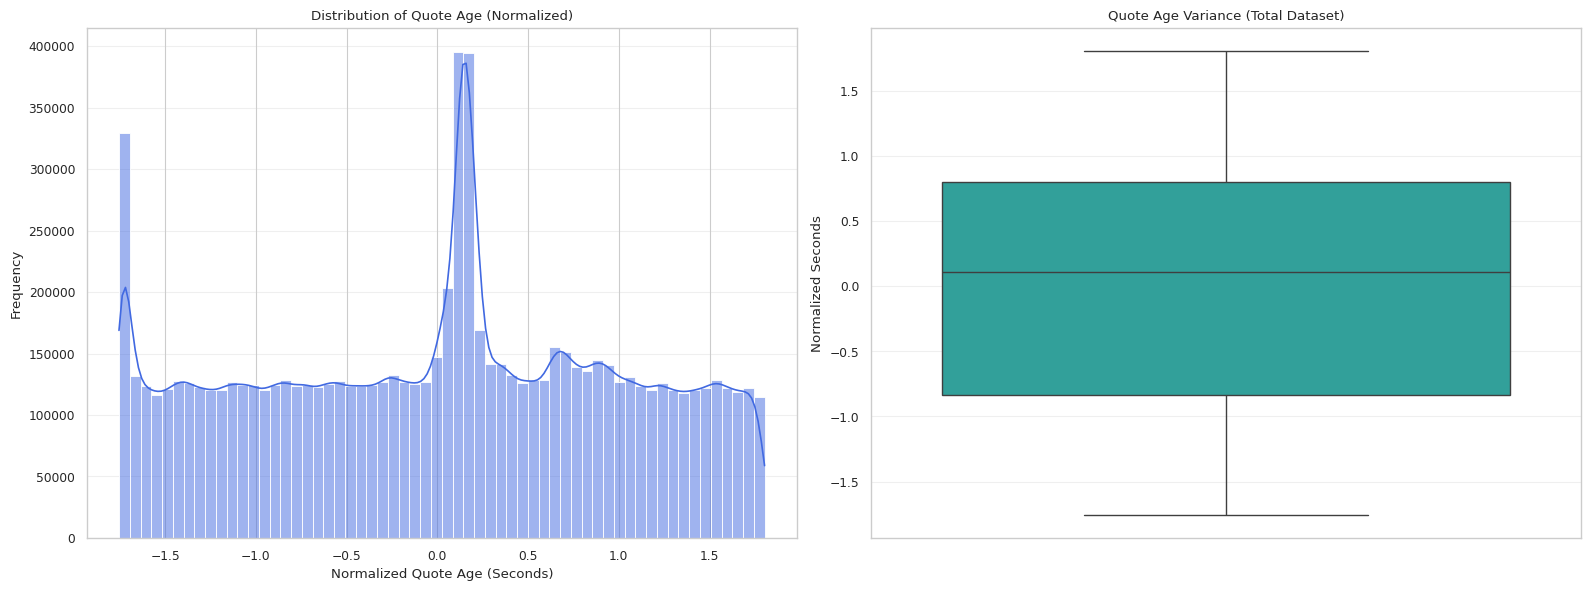

Summary Statistics for Processed Quote Age:


,quote_age_seconds
count,8.509326e+06
mean,2.873578e-09
std,9.954480e-01
min,-1.754497e+00
25%,-8.334557e-01
50%,1.113036e-01
75%,8.001083e-01
max,1.803174e+00


In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df_final['quote_age_seconds'], bins=60, kde=True, ax=ax1, color='royalblue')
ax1.set_title("Distribution of Quote Age (Normalized)")
ax1.set_xlabel("Normalized Quote Age (Seconds)")
ax1.set_ylabel("Frequency")
ax1.grid(axis='y', alpha=0.3)

segment_cols = [c for c in df_final.columns if 'MARKET_SEGMENT' in c]

sns.boxplot(data=df_final, y='quote_age_seconds', ax=ax2, color='lightseagreen')
ax2.set_title("Quote Age Variance (Total Dataset)")
ax2.set_ylabel("Normalized Seconds")
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Summary Statistics for Processed Quote Age:")
display(df_final['quote_age_seconds'].describe())

We calculate the Pearson correlation coefficients to understand the linear relationships between the engineered features and the target absolute error.

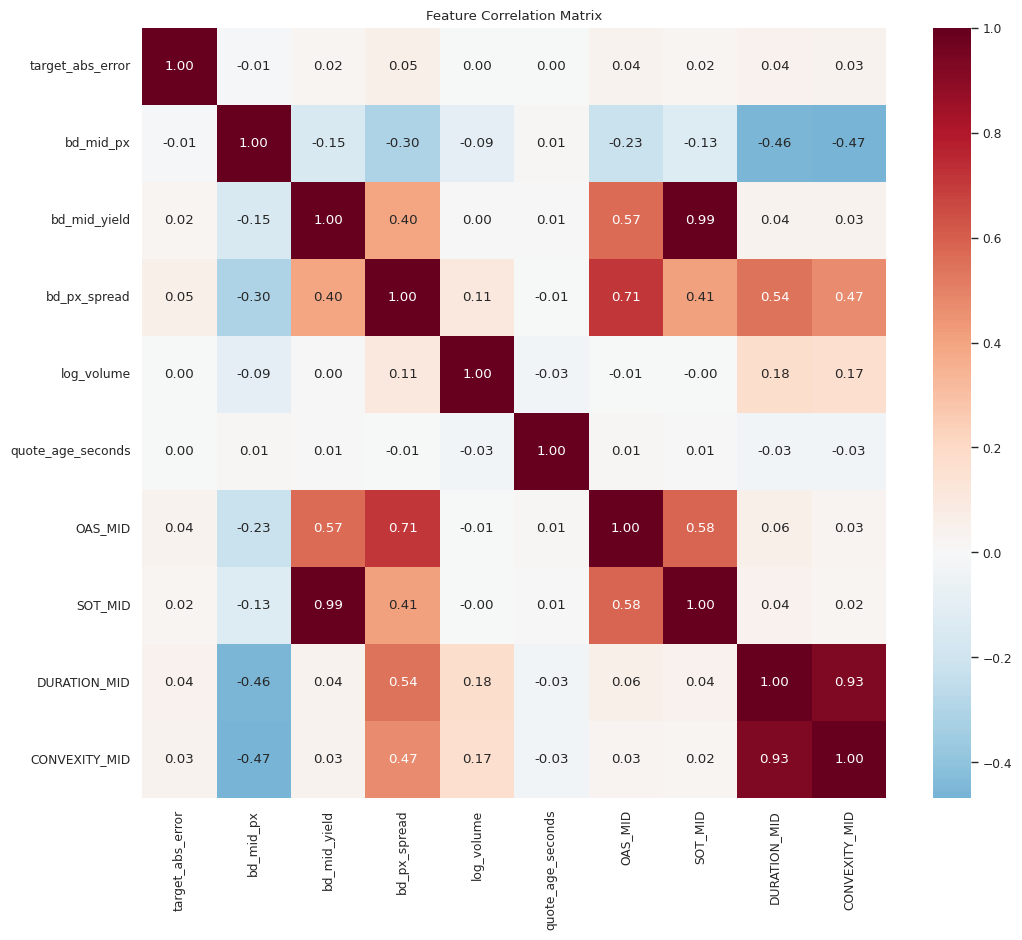

,target_abs_error
target_abs_error,1.000000
bd_px_spread,0.054824
DURATION_MID,0.043552
OAS_MID,0.041222
CONVEXITY_MID,0.034853
SOT_MID,0.023955
bd_mid_yield,0.023237
quote_age_seconds,0.000406
log_volume,0.000383
bd_mid_px,-0.011943


In [19]:
corr_cols = [
    'target_abs_error', 'bd_mid_px', 'bd_mid_yield', 'bd_px_spread',
    'log_volume', 'quote_age_seconds', 'OAS_MID', 'SOT_MID',
    'DURATION_MID', 'CONVEXITY_MID']

corr_matrix = df_final[corr_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='RdBu_r', center=0)
plt.title("Feature Correlation Matrix")
plt.show()

display(corr_matrix['target_abs_error'].sort_values(ascending=False))